# ⚡ Advanced Energy Consumption Forecasting
### End-to-End ML Pipeline — Feature Engineering → Model Training → Future Prediction

---

**Dataset:** Hourly electricity consumption (MWh), 2016–2021  
**Objective:** Forecast future energy consumption for any custom date range  
**Models:** Linear Baseline · Random Forest · XGBoost · LightGBM · Prophet · LSTM

---

### 📋 Pipeline Overview
```
Raw Data → EDA → Feature Engineering → Model Training → Evaluation → Future Forecasting
```

## 📦 1. Imports & Configuration

In [1]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os
import warnings
import pickle
import json
from pathlib import Path

# ─── Data Manipulation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Sklearn ─────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              mean_absolute_percentage_error, r2_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
import joblib

# ─── Gradient Boosting ───────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb

# ─── Prophet ─────────────────────────────────────────────────────────────────
from prophet import Prophet
from prophet.diagnostics import performance_metrics

# ─── Deep Learning ───────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization,
                                      Bidirectional, Conv1D, MaxPooling1D, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ─── Config ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']
sns.set_palette(PALETTE)

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ All libraries loaded successfully!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   XGBoost version    : {xgb.__version__}")
print(f"   LightGBM version   : {lgb.__version__}")

2026-05-03 08:44:36.930992: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777797877.263906      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777797877.363925      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777797878.315461      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777797878.315508      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777797878.315511      57 computation_placer.cc:177] computation placer alr

✅ All libraries loaded successfully!
   TensorFlow version : 2.19.0
   XGBoost version    : 3.2.0
   LightGBM version   : 4.6.0


## 🗂️ 2. Paths & Directory Setup (Kaggle-Compatible)

In [2]:
# ─── Kaggle / Local Path Detection ───────────────────────────────────────────
IS_KAGGLE = Path('/kaggle').exists()

if IS_KAGGLE:
    # Kaggle paths — update the dataset slug to match your Kaggle dataset name
    DATASET_SLUG = 'energy-consumption-dataset'   # <-- Change this to your dataset slug
    DATA_PATH = Path('/kaggle/input/datasets/harshvardhansg/energy/Energy Consumption Dataset.xlsx')
    OUTPUT_DIR = Path('/kaggle/working/models')
    PLOT_DIR   = Path('/kaggle/working/plots')
else:
    # Local / Colab paths
    DATA_PATH  = Path('Energy_Consumption_Dataset.xlsx')
    OUTPUT_DIR = Path('models')
    PLOT_DIR   = Path('plots')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"🖥️  Running on {'Kaggle' if IS_KAGGLE else 'Local/Colab'}")
print(f"📂  Data path   : {DATA_PATH}")
print(f"💾  Models dir  : {OUTPUT_DIR}")
print(f"📊  Plots dir   : {PLOT_DIR}")

🖥️  Running on Kaggle
📂  Data path   : /kaggle/input/datasets/harshvardhansg/energy/Energy Consumption Dataset.xlsx
💾  Models dir  : /kaggle/working/models
📊  Plots dir   : /kaggle/working/plots


## 📥 3. Data Loading & Initial Inspection

In [3]:
# ─── Load Raw Data ────────────────────────────────────────────────────────────
df_raw = pd.read_excel(DATA_PATH)

# Rename columns for convenience
df_raw.columns = ['start_time', 'end_time', 'consumption_mwh']

# Ensure datetime types
df_raw['start_time'] = pd.to_datetime(df_raw['start_time'])
df_raw['end_time']   = pd.to_datetime(df_raw['end_time'])

# Use start_time as the primary index
df_raw = df_raw.sort_values('start_time').reset_index(drop=True)

print("=" * 55)
print("         DATASET SUMMARY")
print("=" * 55)
print(f"  Rows            : {len(df_raw):,}")
print(f"  Columns         : {df_raw.columns.tolist()}")
print(f"  Start date      : {df_raw['start_time'].min()}")
print(f"  End date        : {df_raw['start_time'].max()}")
print(f"  Years covered   : {df_raw['start_time'].dt.year.nunique()}")
print(f"  Missing values  : {df_raw.isnull().sum().sum()}")
print("=" * 55)
print()

print("📋 First 5 rows:")
df_raw.head()

         DATASET SUMMARY
  Rows            : 52,966
  Columns         : ['start_time', 'end_time', 'consumption_mwh']
  Start date      : 2015-12-31 21:00:00
  End date        : 2021-12-31 20:00:00
  Years covered   : 7
  Missing values  : 0

📋 First 5 rows:


,start_time,end_time,consumption_mwh
0,2015-12-31 21:00:00,2015-12-31 22:00:00,10800
1,2015-12-31 22:00:00,2015-12-31 23:00:00,10431
2,2015-12-31 23:00:00,2016-01-01 00:00:00,10005
3,2016-01-01 00:00:00,2016-01-01 01:00:00,9722
4,2016-01-01 01:00:00,2016-01-01 02:00:00,9599


In [4]:
# ─── Statistical Overview ────────────────────────────────────────────────────
stats = df_raw['consumption_mwh'].describe()
print("📊 Consumption Statistics (MWh):")
print(stats.to_string())
print(f"\n  Coefficient of Variation : {(stats['std'] / stats['mean'] * 100):.2f}%")
print(f"  Skewness                 : {df_raw['consumption_mwh'].skew():.4f}")
print(f"  Kurtosis                 : {df_raw['consumption_mwh'].kurt():.4f}")

# Verify hourly intervals
time_diffs = df_raw['start_time'].diff().dropna()
print(f"\n⏱️  Time interval check:")
print(f"  Most common interval     : {time_diffs.mode()[0]}")
print(f"  Non-hourly records       : {(time_diffs != pd.Timedelta(hours=1)).sum()}")

📊 Consumption Statistics (MWh):
count   52966.00
mean     9488.75
std      1576.24
min      5341.00
25%      8322.00
50%      9277.00
75%     10602.00
max     15105.00

  Coefficient of Variation : 16.61%
  Skewness                 : 0.4014
  Kurtosis                 : -0.3345

⏱️  Time interval check:
  Most common interval     : 0 days 01:00:00
  Non-hourly records       : 1247


## 🔍 4. Exploratory Data Analysis (EDA)

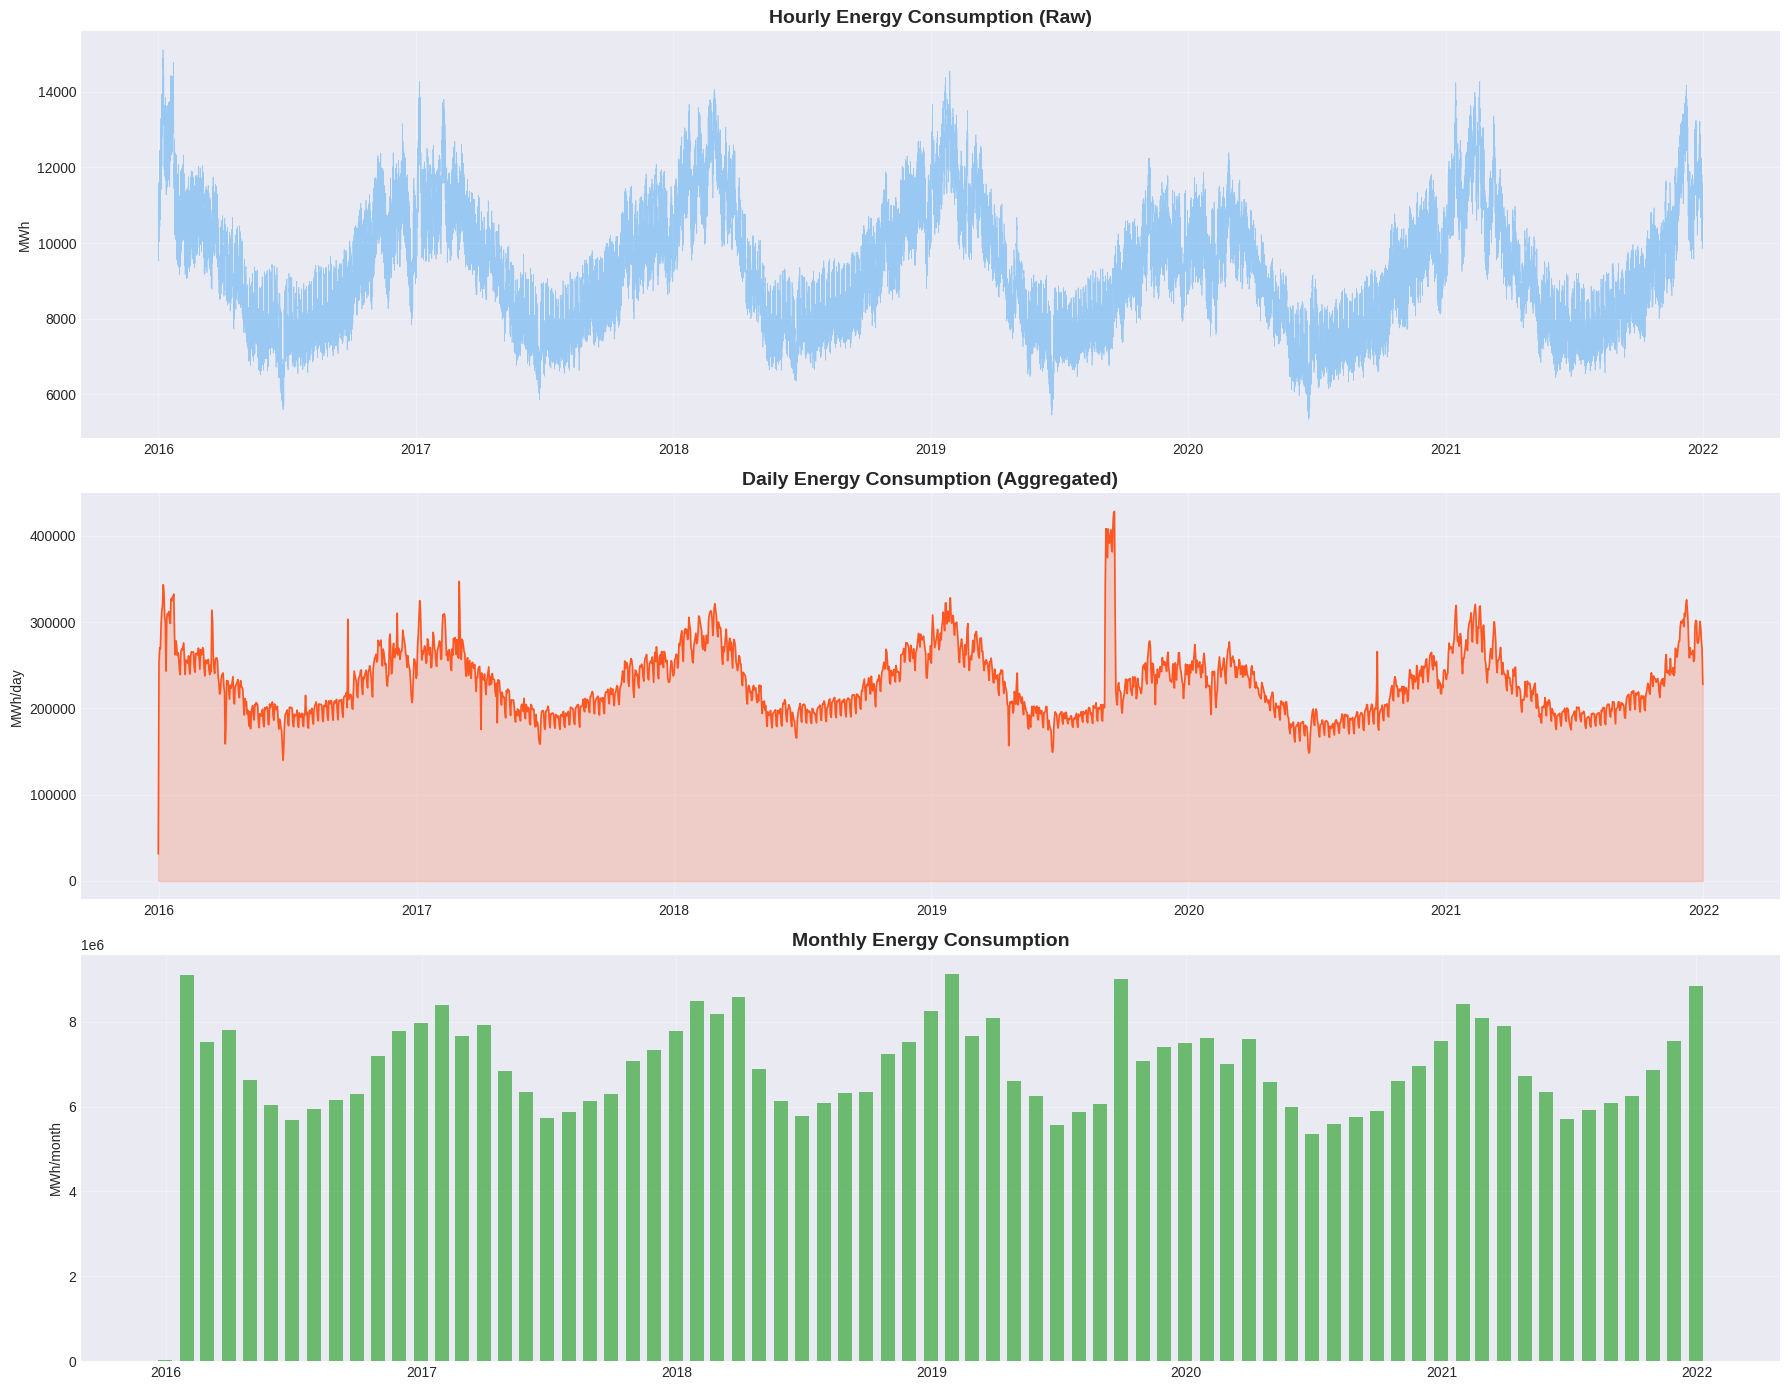

✅ Saved: eda_time_series_overview.png


In [5]:
# ─── 4.1 Full Time Series Overview ──────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

# Daily resampled view
daily = df_raw.set_index('start_time')['consumption_mwh'].resample('D').sum()
monthly = df_raw.set_index('start_time')['consumption_mwh'].resample('ME').sum()

# Raw hourly
axes[0].plot(df_raw['start_time'], df_raw['consumption_mwh'],
             alpha=0.4, linewidth=0.5, color=PALETTE[0])
axes[0].set_title('Hourly Energy Consumption (Raw)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MWh')

# Daily aggregated
axes[1].plot(daily.index, daily.values, linewidth=1.2, color=PALETTE[1])
axes[1].fill_between(daily.index, daily.values, alpha=0.2, color=PALETTE[1])
axes[1].set_title('Daily Energy Consumption (Aggregated)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MWh/day')

# Monthly aggregated
axes[2].bar(monthly.index, monthly.values, width=20, color=PALETTE[2], alpha=0.8)
axes[2].set_title('Monthly Energy Consumption', fontsize=14, fontweight='bold')
axes[2].set_ylabel('MWh/month')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_time_series_overview.png")

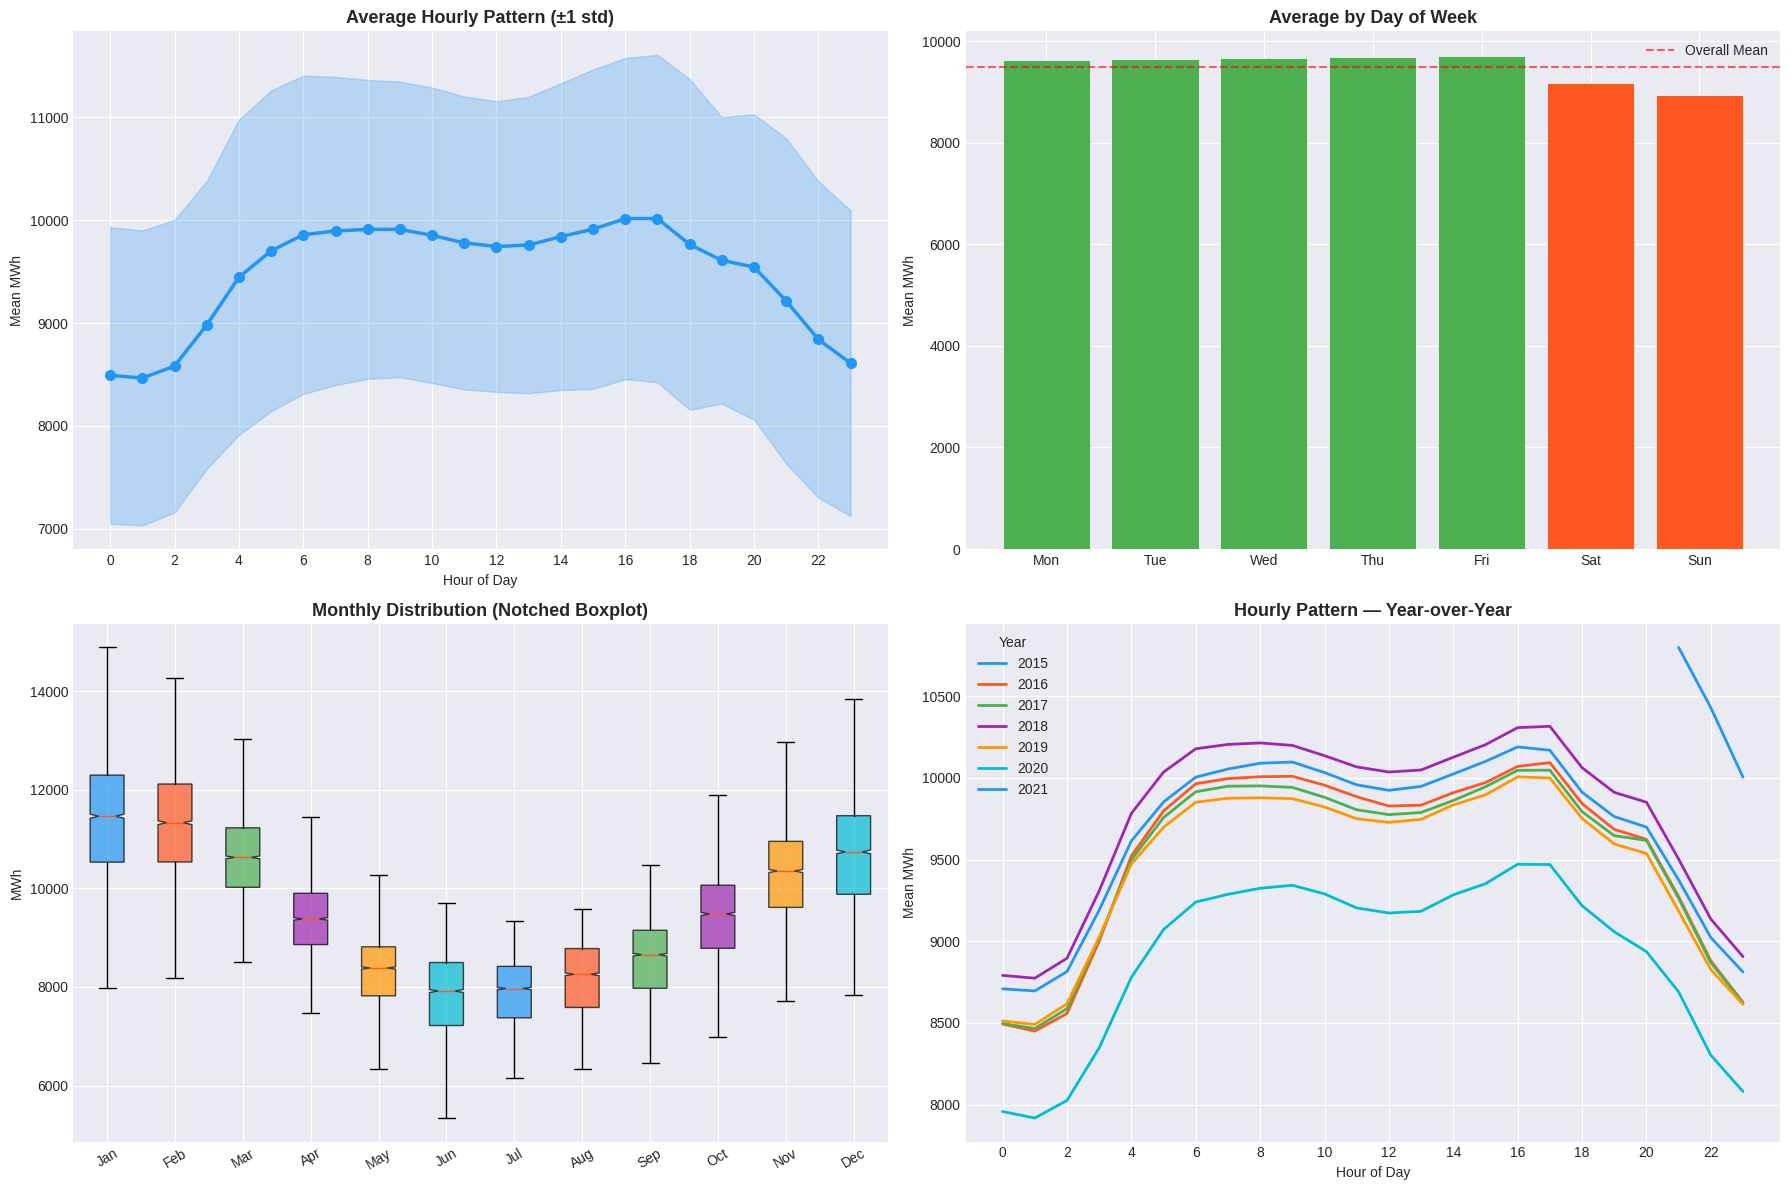

✅ Saved: eda_seasonal_patterns.png


In [6]:
# ─── 4.2 Seasonal & Cyclic Patterns ─────────────────────────────────────────
df_eda = df_raw.copy()
df_eda['hour']    = df_eda['start_time'].dt.hour
df_eda['dow']     = df_eda['start_time'].dt.dayofweek   # 0=Mon
df_eda['month']   = df_eda['start_time'].dt.month
df_eda['year']    = df_eda['start_time'].dt.year
df_eda['is_wknd'] = (df_eda['dow'] >= 5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Hourly pattern
hourly_avg = df_eda.groupby('hour')['consumption_mwh'].agg(['mean', 'std'])
ax = axes[0, 0]
ax.plot(hourly_avg.index, hourly_avg['mean'], marker='o', linewidth=2.5,
        color=PALETTE[0], markersize=7)
ax.fill_between(hourly_avg.index,
                hourly_avg['mean'] - hourly_avg['std'],
                hourly_avg['mean'] + hourly_avg['std'],
                alpha=0.25, color=PALETTE[0])
ax.set_title('Average Hourly Pattern (±1 std)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean MWh')
ax.set_xticks(range(0, 24, 2))

# Day-of-week pattern
dow_avg = df_eda.groupby('dow')['consumption_mwh'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = [PALETTE[2] if i < 5 else PALETTE[1] for i in range(7)]
axes[0, 1].bar(day_names, dow_avg.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0, 1].set_title('Average by Day of Week', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Mean MWh')
axes[0, 1].axhline(dow_avg.mean(), color='red', linestyle='--', alpha=0.6, label='Overall Mean')
axes[0, 1].legend()

# Monthly pattern (boxplot)
month_data = [df_eda[df_eda['month'] == m]['consumption_mwh'].values for m in range(1, 13)]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bp = axes[1, 0].boxplot(month_data, labels=month_names, patch_artist=True,
                         notch=True, showfliers=False)
for patch, color in zip(bp['boxes'], PALETTE * 2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Monthly Distribution (Notched Boxplot)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('MWh')
axes[1, 0].tick_params(axis='x', rotation=30)

# Year-over-year
yearly_hourly = df_eda.groupby(['year', 'hour'])['consumption_mwh'].mean().unstack(0)
for i, year in enumerate(yearly_hourly.columns):
    axes[1, 1].plot(yearly_hourly.index, yearly_hourly[year],
                    label=str(year), linewidth=2, color=PALETTE[i % len(PALETTE)])
axes[1, 1].set_title('Hourly Pattern — Year-over-Year', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Mean MWh')
axes[1, 1].legend(title='Year', loc='upper left')
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_seasonal_patterns.png")

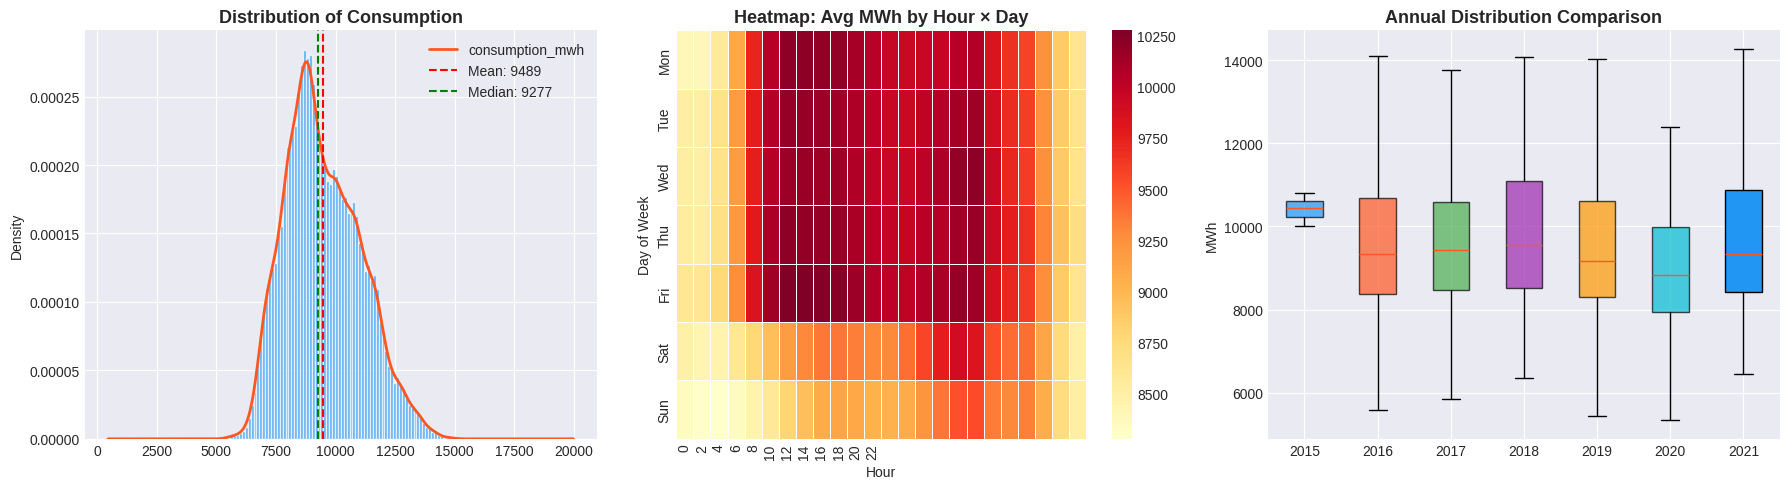

✅ Saved: eda_distribution.png


In [7]:
# ─── 4.3 Distribution & Outlier Analysis ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram with KDE
axes[0].hist(df_raw['consumption_mwh'], bins=80, density=True,
             color=PALETTE[0], alpha=0.7, edgecolor='white')
df_raw['consumption_mwh'].plot.kde(ax=axes[0], color=PALETTE[1], linewidth=2)
axes[0].axvline(df_raw['consumption_mwh'].mean(), color='red',
                linestyle='--', label=f"Mean: {df_raw['consumption_mwh'].mean():.0f}")
axes[0].axvline(df_raw['consumption_mwh'].median(), color='green',
                linestyle='--', label=f"Median: {df_raw['consumption_mwh'].median():.0f}")
axes[0].set_title('Distribution of Consumption', fontsize=13, fontweight='bold')
axes[0].legend()

# Heatmap: Hour × Day of Week
pivot = df_eda.groupby(['dow', 'hour'])['consumption_mwh'].mean().unstack()
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', fmt='.0f',
            xticklabels=range(0, 24, 2), yticklabels=day_names,
            linewidths=0.5)
axes[1].set_title('Heatmap: Avg MWh by Hour × Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Day of Week')

# Year-over-year box
yearly_data = [df_eda[df_eda['year'] == y]['consumption_mwh'].values
               for y in sorted(df_eda['year'].unique())]
bpy = axes[2].boxplot(yearly_data,
                      labels=sorted(df_eda['year'].unique()),
                      patch_artist=True, showfliers=False)
for patch, color in zip(bpy['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Annual Distribution Comparison', fontsize=13, fontweight='bold')
axes[2].set_ylabel('MWh')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_distribution.png")

## 🔧 5. Advanced Feature Engineering

We build **5 categories** of features:

| Category | Features |
|---|---|
| **Calendric** | Hour, Day, Month, Year, DOW, Quarter |
| **Cyclical Encoding** | Sin/Cos transforms for hour, DOW, month (avoids ordinal bias) |
| **Lag Features** | Previous 1h, 2h, 3h, 24h, 48h, 168h (1 week) consumption |
| **Rolling Statistics** | 3h/6h/24h/168h rolling mean, std, min, max |
| **Fourier Terms** | Captures daily & weekly seasonality as harmonics |


In [8]:
def build_features(df: pd.DataFrame, target_col: str = 'consumption_mwh') -> pd.DataFrame:
    """
    Comprehensive feature engineering for hourly energy time series.
    
    Parameters
    ----------
    df : DataFrame with 'start_time' (datetime) and target_col.
    target_col : Name of the target variable column.
    
    Returns
    -------
    DataFrame with all engineered features.
    """
    data = df.copy().set_index('start_time').sort_index()
    t = data.index  # DatetimeIndex

    # ── 5.1 Basic Calendric Features ────────────────────────────────────────
    data['hour']          = t.hour
    data['day_of_week']   = t.dayofweek          # 0 = Monday
    data['day_of_month']  = t.day
    data['day_of_year']   = t.dayofyear
    data['week_of_year']  = t.isocalendar().week.astype(int)
    data['month']         = t.month
    data['quarter']       = t.quarter
    data['year']          = t.year
    data['is_weekend']    = (t.dayofweek >= 5).astype(int)
    data['is_month_start'] = t.is_month_start.astype(int)
    data['is_month_end']   = t.is_month_end.astype(int)

    # ── 5.2 Season (Meteorological) ─────────────────────────────────────────
    season_map = {12: 0, 1: 0, 2: 0,    # Winter
                   3: 1, 4: 1, 5: 1,    # Spring
                   6: 2, 7: 2, 8: 2,    # Summer
                   9: 3, 10: 3, 11: 3}  # Autumn
    data['season'] = data['month'].map(season_map)

    # ── 5.3 Time of Day Bins ─────────────────────────────────────────────────
    # 0=Night(0-5), 1=Morning(6-11), 2=Afternoon(12-17), 3=Evening(18-23)
    data['time_of_day'] = pd.cut(data['hour'],
                                  bins=[-1, 5, 11, 17, 23],
                                  labels=[0, 1, 2, 3]).astype(int)

    # ── 5.4 Cyclical Encoding (sin/cos) ──────────────────────────────────────
    # Prevents the model treating 23:00 and 00:00 as "far apart"
    data['hour_sin']   = np.sin(2 * np.pi * data['hour']   / 24)
    data['hour_cos']   = np.cos(2 * np.pi * data['hour']   / 24)
    data['dow_sin']    = np.sin(2 * np.pi * data['day_of_week']  / 7)
    data['dow_cos']    = np.cos(2 * np.pi * data['day_of_week']  / 7)
    data['month_sin']  = np.sin(2 * np.pi * data['month']  / 12)
    data['month_cos']  = np.cos(2 * np.pi * data['month']  / 12)
    data['doy_sin']    = np.sin(2 * np.pi * data['day_of_year'] / 365.25)
    data['doy_cos']    = np.cos(2 * np.pi * data['day_of_year'] / 365.25)

    # ── 5.5 Lag Features ─────────────────────────────────────────────────────
    # Key lags: 1h, 2h, 3h, 6h, 12h, 24h (same hour yesterday),
    #           48h (2 days ago), 168h (same hour last week)
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        data[f'lag_{lag}h'] = data[target_col].shift(lag)

    # Same day last week (168h) — strong seasonal signal
    data['lag_1w'] = data[target_col].shift(168)
    # Same time yesterday
    data['lag_1d'] = data[target_col].shift(24)

    # ── 5.6 Rolling Window Statistics ────────────────────────────────────────
    windows = {'3h': 3, '6h': 6, '12h': 12, '24h': 24, '48h': 48, '1w': 168}
    for name, w in windows.items():
        roll = data[target_col].shift(1).rolling(window=w, min_periods=1)
        data[f'roll_mean_{name}']  = roll.mean()
        data[f'roll_std_{name}']   = roll.std()
        data[f'roll_min_{name}']   = roll.min()
        data[f'roll_max_{name}']   = roll.max()

    # ── 5.7 Expanding Window (Overall Trend) ─────────────────────────────────
    data['expand_mean'] = data[target_col].shift(1).expanding().mean()

    # ── 5.8 Fourier Harmonics (Captures Complex Seasonality) ─────────────────
    # t_idx = integer time index (0, 1, 2, ...)
    t_idx = np.arange(len(data))
    # Daily harmonics (period = 24h)
    for k in [1, 2, 3]:
        data[f'fourier_daily_sin_{k}'] = np.sin(2 * np.pi * k * t_idx / 24)
        data[f'fourier_daily_cos_{k}'] = np.cos(2 * np.pi * k * t_idx / 24)
    # Weekly harmonics (period = 168h)
    for k in [1, 2]:
        data[f'fourier_weekly_sin_{k}'] = np.sin(2 * np.pi * k * t_idx / 168)
        data[f'fourier_weekly_cos_{k}'] = np.cos(2 * np.pi * k * t_idx / 168)

    # ── 5.9 Interaction Features ──────────────────────────────────────────────
    data['hour_x_weekend'] = data['hour'] * data['is_weekend']
    data['hour_x_season']  = data['hour'] * data['season']
    data['month_x_year']   = data['month'] * (data['year'] - data['year'].min())

    # ── 5.10 Drop 'end_time' if present ──────────────────────────────────────
    if 'end_time' in data.columns:
        data = data.drop(columns=['end_time'])

    return data.reset_index()


print("⚙️  Building features...")
df_feat = build_features(df_raw)

# Drop rows with NaN from lags (first 168 rows)
df_feat = df_feat.dropna().reset_index(drop=True)

print(f"✅ Feature engineering complete!")
print(f"   Original features : 3")
print(f"   Engineered total  : {df_feat.shape[1]}")
print(f"   Rows retained     : {len(df_feat):,} / {len(df_raw):,}")

⚙️  Building features...
✅ Feature engineering complete!
   Original features : 3
   Engineered total  : 71
   Rows retained     : 52,798 / 52,966


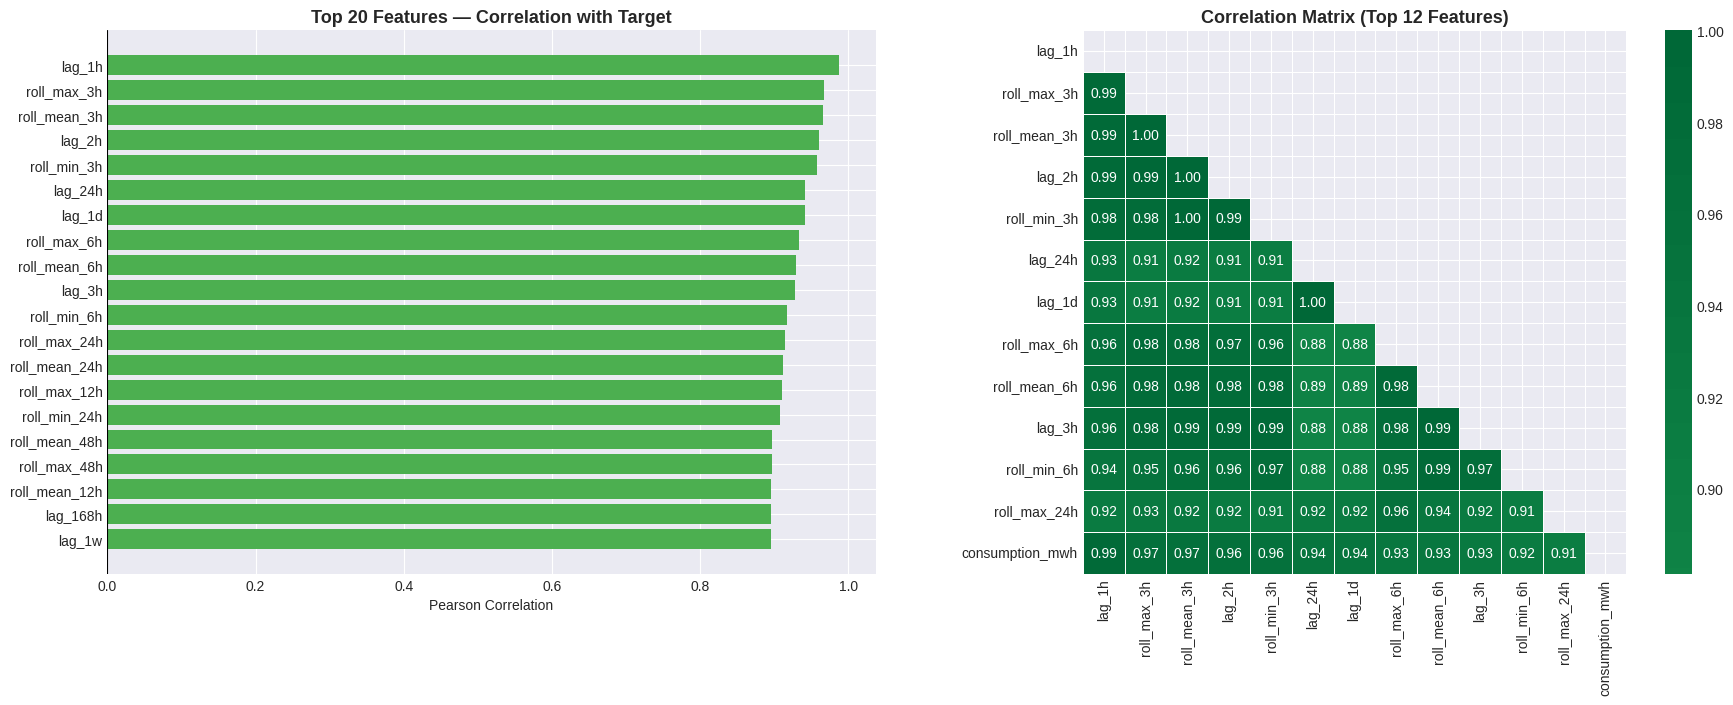

✅ Saved: feature_correlation.png


In [9]:
# ─── Feature Correlation Heatmap ────────────────────────────────────────────
# Top features correlated with target
target = 'consumption_mwh'
feature_cols = [c for c in df_feat.columns if c not in ['start_time', target]]

corr_with_target = df_feat[feature_cols + [target]].corr()[target].drop(target)
top_features_by_corr = corr_with_target.abs().nlargest(20).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of top correlations
corr_vals = corr_with_target[top_features_by_corr]
colors_bar = [PALETTE[2] if v > 0 else PALETTE[1] for v in corr_vals.values]
axes[0].barh(top_features_by_corr[::-1], corr_vals.values[::-1], color=colors_bar[::-1])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 20 Features — Correlation with Target', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')

# Correlation matrix among top features
top_12 = corr_with_target.abs().nlargest(12).index.tolist()
corr_matrix = df_feat[top_12 + [target]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True, linewidths=0.5)
axes[1].set_title('Correlation Matrix (Top 12 Features)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_correlation.png")

## ✂️ 6. Train / Validation / Test Split

We use a **chronological split** (never shuffle time series!):
- **Train**: 2016 → 2019 (≈80%)
- **Validation**: 2020 (≈10%)
- **Test**: 2021 (≈10%)

In [10]:
# ─── Define Feature Columns ──────────────────────────────────────────────────
TARGET = 'consumption_mwh'
FEATURES = [c for c in df_feat.columns if c not in ['start_time', TARGET]]

print(f"📌 Total feature count : {len(FEATURES)}")
print(f"   Features: {FEATURES}")

# ─── Chronological Split ─────────────────────────────────────────────────────
TRAIN_END = '2019-12-31 23:00:00'
VAL_END   = '2020-12-31 23:00:00'

mask_train = df_feat['start_time'] <= TRAIN_END
mask_val   = (df_feat['start_time'] > TRAIN_END) & (df_feat['start_time'] <= VAL_END)
mask_test  = df_feat['start_time'] > VAL_END

X_train = df_feat.loc[mask_train, FEATURES]
y_train = df_feat.loc[mask_train, TARGET]
X_val   = df_feat.loc[mask_val,   FEATURES]
y_val   = df_feat.loc[mask_val,   TARGET]
X_test  = df_feat.loc[mask_test,  FEATURES]
y_test  = df_feat.loc[mask_test,  TARGET]

print(f"\n📊 Dataset splits:")
print(f"   Train set  : {len(X_train):>7,} rows  ({df_feat.loc[mask_train,'start_time'].min().date()} → {df_feat.loc[mask_train,'start_time'].max().date()})")
print(f"   Val set    : {len(X_val):>7,} rows  ({df_feat.loc[mask_val,  'start_time'].min().date()} → {df_feat.loc[mask_val,  'start_time'].max().date()})")
print(f"   Test set   : {len(X_test):>7,} rows  ({df_feat.loc[mask_test, 'start_time'].min().date()} → {df_feat.loc[mask_test, 'start_time'].max().date()})")

# ─── Feature Scaling ──────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, OUTPUT_DIR / 'feature_scaler.pkl')
print(f"\n✅ Scaler saved → {OUTPUT_DIR / 'feature_scaler.pkl'}")

📌 Total feature count : 69
   Features: ['hour', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'month', 'quarter', 'year', 'is_weekend', 'is_month_start', 'is_month_end', 'season', 'time_of_day', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'lag_1w', 'lag_1d', 'roll_mean_3h', 'roll_std_3h', 'roll_min_3h', 'roll_max_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_min_6h', 'roll_max_6h', 'roll_mean_12h', 'roll_std_12h', 'roll_min_12h', 'roll_max_12h', 'roll_mean_24h', 'roll_std_24h', 'roll_min_24h', 'roll_max_24h', 'roll_mean_48h', 'roll_std_48h', 'roll_min_48h', 'roll_max_48h', 'roll_mean_1w', 'roll_std_1w', 'roll_min_1w', 'roll_max_1w', 'expand_mean', 'fourier_daily_sin_1', 'fourier_daily_cos_1', 'fourier_daily_sin_2', 'fourier_daily_cos_2', 'fourier_daily_sin_3', 'fourier_daily_cos_3', 'fourier_weekly_sin_1', 'fourier_weekly_cos_1', 'fourier_w

## 🤖 7. Model Training & Saving

All models are trained and saved after fitting. We evaluate using:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **MAPE** (Mean Absolute Percentage Error)
- **R²** (Coefficient of Determination)

In [11]:
# ─── Evaluation Helper ───────────────────────────────────────────────────────
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """Compute and print all regression metrics."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    
    print(f"  {'Model':<20}: {model_name}")
    print(f"  {'MAE':<20}: {mae:>10.2f} MWh")
    print(f"  {'RMSE':<20}: {rmse:>10.2f} MWh")
    print(f"  {'MAPE':<20}: {mape:>10.2f}%")
    print(f"  {'R²':<20}: {r2:>10.4f}")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results_log = []  # Will collect all model metrics

In [12]:
# ─── 7.1 Baseline: Ridge Regression ──────────────────────────────────────────
print("=" * 50)
print(" MODEL 1: Ridge Regression (Baseline)")
print("=" * 50)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

# Predict on validation
y_pred_ridge = ridge.predict(X_val_sc)
metrics_ridge = evaluate_model(y_val, y_pred_ridge, 'Ridge Regression')
results_log.append(metrics_ridge)

# SAVE MODEL
joblib.dump(ridge, OUTPUT_DIR / 'ridge_regression.pkl')
print(f"\n💾 Saved → {OUTPUT_DIR / 'ridge_regression.pkl'}")

 MODEL 1: Ridge Regression (Baseline)
  Model               : Ridge Regression
  MAE                 :     112.20 MWh
  RMSE                :     152.18 MWh
  MAPE                :       1.27%
  R²                  :     0.9865

💾 Saved → /kaggle/working/models/ridge_regression.pkl


In [13]:
# ─── 7.2 Random Forest ───────────────────────────────────────────────────────
print("=" * 50)
print(" MODEL 2: Random Forest Regressor")
print("=" * 50)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=4,
    max_features=0.6,
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)
rf.fit(X_train, y_train)   # RF works on unscaled data

y_pred_rf = rf.predict(X_val)
metrics_rf = evaluate_model(y_val, y_pred_rf, 'Random Forest')
results_log.append(metrics_rf)

# SAVE MODEL
joblib.dump(rf, OUTPUT_DIR / 'random_forest.pkl')
print(f"\n💾 Saved → {OUTPUT_DIR / 'random_forest.pkl'}")

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).nlargest(15)
print(f"\n🌲 Top 15 feature importances (Random Forest):")
print(feat_imp.to_string())

 MODEL 2: Random Forest Regressor
  Model               : Random Forest
  MAE                 :      88.87 MWh
  RMSE                :     124.99 MWh
  MAPE                :       1.01%
  R²                  :     0.9909

💾 Saved → /kaggle/working/models/random_forest.pkl

🌲 Top 15 feature importances (Random Forest):
lag_1h         0.61
roll_max_3h    0.19
roll_mean_3h   0.10
lag_2h         0.04
roll_min_3h    0.02
lag_24h        0.01
lag_1d         0.01
hour           0.01
hour_sin       0.00
time_of_day    0.00
hour_cos       0.00
lag_168h       0.00
lag_1w         0.00
roll_std_3h    0.00
roll_mean_6h   0.00


In [14]:
# ─── 7.3 XGBoost ─────────────────────────────────────────────────────────────
print("=" * 50)
print(" MODEL 3: XGBoost Regressor")
print("=" * 50)

xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='rmse',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_val)
metrics_xgb = evaluate_model(y_val, y_pred_xgb, 'XGBoost')
results_log.append(metrics_xgb)

# SAVE MODEL
xgb_model.save_model(str(OUTPUT_DIR / 'xgboost_model.json'))
print(f"\n💾 Saved → {OUTPUT_DIR / 'xgboost_model.json'}")

 MODEL 3: XGBoost Regressor
  Model               : XGBoost
  MAE                 :      83.63 MWh
  RMSE                :     120.93 MWh
  MAPE                :       0.95%
  R²                  :     0.9915

💾 Saved → /kaggle/working/models/xgboost_model.json


In [15]:
# ─── 7.4 LightGBM ────────────────────────────────────────────────────────────
print("=" * 50)
print(" MODEL 4: LightGBM Regressor")
print("=" * 50)

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)

lgb_params = {
    'objective':       'regression',
    'metric':          'rmse',
    'num_leaves':      127,
    'learning_rate':   0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':    5,
    'reg_alpha':       0.1,
    'reg_lambda':      0.5,
    'verbose':        -1,
    'random_state':    SEED,
}

lgb_callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=-1)
]

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=lgb_callbacks
)

y_pred_lgb = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
metrics_lgb = evaluate_model(y_val, y_pred_lgb, 'LightGBM')
results_log.append(metrics_lgb)

# SAVE MODEL
lgb_model.save_model(str(OUTPUT_DIR / 'lightgbm_model.txt'))
print(f"\n💾 Saved → {OUTPUT_DIR / 'lightgbm_model.txt'}")

 MODEL 4: LightGBM Regressor
  Model               : LightGBM
  MAE                 :      82.03 MWh
  RMSE                :     119.11 MWh
  MAPE                :       0.93%
  R²                  :     0.9918

💾 Saved → /kaggle/working/models/lightgbm_model.txt


In [16]:
# ─── 7.5 Prophet (Time-Series Decomposition Model) ───────────────────────────
print("=" * 50)
print(" MODEL 5: Facebook Prophet")
print("=" * 50)

# Prophet requires columns named 'ds' and 'y'
# Use daily aggregated data for efficiency
df_prophet_train = (
    df_raw[df_raw['start_time'] <= TRAIN_END]
    .set_index('start_time')['consumption_mwh']
    .resample('D').sum()
    .reset_index()
    .rename(columns={'start_time': 'ds', 'consumption_mwh': 'y'})
)

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10.0,
    interval_width=0.90
)
prophet_model.fit(df_prophet_train)

# Validate on 2020
df_prophet_val = (
    df_raw[(df_raw['start_time'] > TRAIN_END) & (df_raw['start_time'] <= VAL_END)]
    .set_index('start_time')['consumption_mwh']
    .resample('D').sum()
    .reset_index()
    .rename(columns={'start_time': 'ds', 'consumption_mwh': 'y'})
)
val_forecast = prophet_model.predict(df_prophet_val[['ds']])
metrics_prophet = evaluate_model(df_prophet_val['y'], val_forecast['yhat'], 'Prophet (daily)')
results_log.append(metrics_prophet)

# SAVE MODEL
with open(OUTPUT_DIR / 'prophet_model.pkl', 'wb') as f:
    pickle.dump(prophet_model, f)
print(f"\n💾 Saved → {OUTPUT_DIR / 'prophet_model.pkl'}")

 MODEL 5: Facebook Prophet


08:47:40 - cmdstanpy - INFO - Chain [1] start processing
08:47:40 - cmdstanpy - INFO - Chain [1] done processing


  Model               : Prophet (daily)
  MAE                 :   25645.47 MWh
  RMSE                :   32225.51 MWh
  MAPE                :      19.35%
  R²                  :    -0.1151

💾 Saved → /kaggle/working/models/prophet_model.pkl


In [17]:
# ─── 7.6 LSTM (Deep Learning) ────────────────────────────────────────────────
print("=" * 50)
print(" MODEL 6: Bi-directional LSTM (Deep Learning)")
print("=" * 50)

# ── Prepare sequences ──────────────────────────────────────────────────────
LOOKBACK = 72    # Use past 72 hours to predict next hour

# Scale ONLY the consumption for LSTM
lstm_scaler = MinMaxScaler(feature_range=(0, 1))
y_all = df_feat[TARGET].values.reshape(-1, 1)

# Fit scaler only on training data
train_size = mask_train.sum()
lstm_scaler.fit(y_all[:train_size])
y_scaled = lstm_scaler.transform(y_all)

joblib.dump(lstm_scaler, OUTPUT_DIR / 'lstm_scaler.pkl')

def create_sequences(data, lookback: int):
    """Create sliding window sequences for LSTM input."""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(y_scaled, LOOKBACK)

# Align split indices
n_train = train_size - LOOKBACK
n_val   = mask_val.sum()

X_lstm_train = X_seq[:n_train].reshape(-1, LOOKBACK, 1)
y_lstm_train = y_seq[:n_train]
X_lstm_val   = X_seq[n_train:n_train + n_val].reshape(-1, LOOKBACK, 1)
y_lstm_val   = y_seq[n_train:n_train + n_val]
X_lstm_test  = X_seq[n_train + n_val:].reshape(-1, LOOKBACK, 1)
y_lstm_test  = y_seq[n_train + n_val:]

# ── Build Bidirectional LSTM ──────────────────────────────────────────────
lstm_model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True,
                       input_shape=(LOOKBACK, 1))),
    Dropout(0.2),
    BatchNormalization(),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae']
)
lstm_model.summary()

# ── Callbacks ────────────────────────────────────────────────────────────
callbacks_lstm = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(OUTPUT_DIR / 'lstm_best.keras'),
                    save_best_only=True, monitor='val_loss', verbose=0)
]

# ── Train ─────────────────────────────────────────────────────────────────
history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=50,
    batch_size=256,
    callbacks=callbacks_lstm,
    verbose=1
)

# ── Evaluate ──────────────────────────────────────────────────────────────
y_pred_lstm_sc = lstm_model.predict(X_lstm_val, verbose=0)
y_pred_lstm = lstm_scaler.inverse_transform(y_pred_lstm_sc).flatten()
y_true_lstm = lstm_scaler.inverse_transform(y_lstm_val.reshape(-1, 1)).flatten()

metrics_lstm = evaluate_model(y_true_lstm, y_pred_lstm, 'Bidirectional LSTM')
results_log.append(metrics_lstm)

# SAVE FINAL MODEL
lstm_model.save(OUTPUT_DIR / 'lstm_final.keras')
print(f"\n💾 Saved → {OUTPUT_DIR / 'lstm_final.keras'}")
print(f"💾 Saved → {OUTPUT_DIR / 'lstm_best.keras'}")
print(f"💾 Saved → {OUTPUT_DIR / 'lstm_scaler.pkl'}")

 MODEL 6: Bi-directional LSTM (Deep Learning)


I0000 00:00:1777798062.835615      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1777798071.162769     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


138/138 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - loss: 0.0112 - mae: 0.0985 - val_loss: 0.0134 - val_mae: 0.1370 - learning_rate: 0.0010
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0018 - mae: 0.0464 - val_loss: 0.0066 - val_mae: 0.0955 - learning_rate: 0.0010
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0013 - mae: 0.0400 - val_loss: 0.0048 - val_mae: 0.0815 - learning_rate: 0.0010
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.0011 - mae: 0.0359 - val_loss: 0.0028 - val_mae: 0.0617 - learning_rate: 0.0010
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 8.8408e-04 - mae: 0.0325 - val_loss: 0.0019 - val_mae: 0.0496 - learning_rate: 0.0010
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 7.7505e-04 - mae: 0.0303 - val_loss: 0.0028 - val_mae: 0.0648 - learning_rate: 0.0010
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 6.9080e-04 - mae: 0.0286 - val_loss: 0.0021 - val_mae: 0.0567 - learning_rate: 0.00

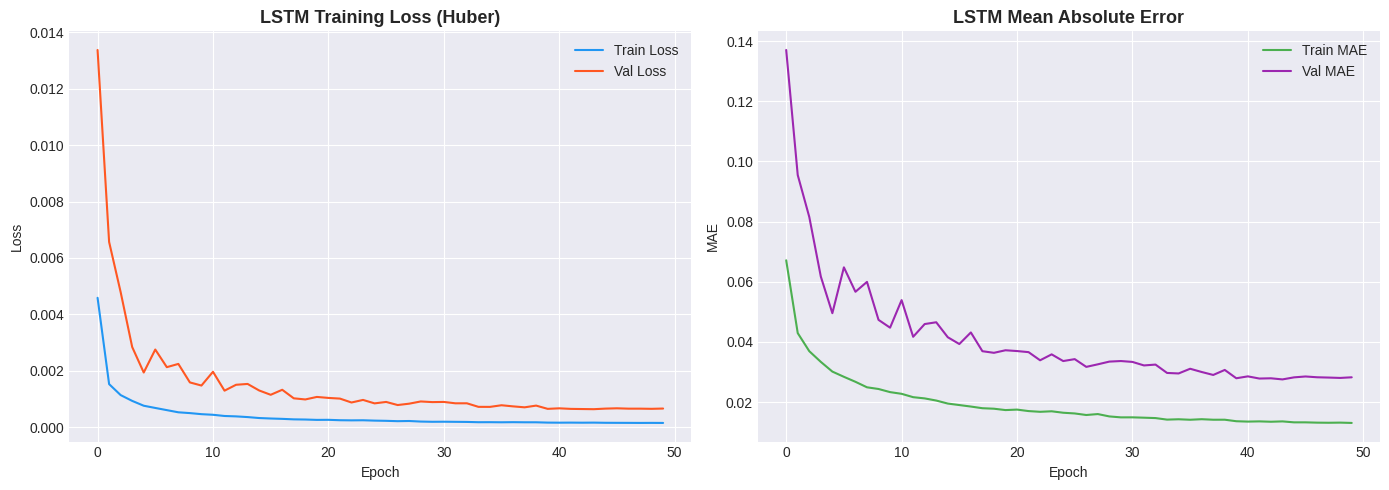

✅ Saved: lstm_training_history.png


In [18]:
# ─── LSTM Training History Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color=PALETTE[0])
axes[0].plot(history.history['val_loss'], label='Val Loss',   color=PALETTE[1])
axes[0].set_title('LSTM Training Loss (Huber)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE', color=PALETTE[2])
axes[1].plot(history.history['val_mae'], label='Val MAE',   color=PALETTE[3])
axes[1].set_title('LSTM Mean Absolute Error', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: lstm_training_history.png")

## 📊 8. Model Comparison & Evaluation on Test Set

In [19]:
# ─── Test Set Evaluation (Final Holdout: 2021) ───────────────────────────────
print("=" * 55)
print("  FINAL TEST SET EVALUATION (2021)")
print("=" * 55)

test_results = []

# Ridge
print("\n▶ Ridge Regression:")
test_results.append(evaluate_model(y_test, ridge.predict(X_test_sc), 'Ridge'))

# Random Forest
print("\n▶ Random Forest:")
test_results.append(evaluate_model(y_test, rf.predict(X_test), 'Random Forest'))

# XGBoost
print("\n▶ XGBoost:")
test_results.append(evaluate_model(y_test, xgb_model.predict(X_test), 'XGBoost'))

# LightGBM
print("\n▶ LightGBM:")
test_results.append(evaluate_model(
    y_test, lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration), 'LightGBM'
))

# Save test results as JSON
with open(OUTPUT_DIR / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)
print(f"\n💾 Saved → {OUTPUT_DIR / 'test_results.json'}")

  FINAL TEST SET EVALUATION (2021)

▶ Ridge Regression:
  Model               : Ridge
  MAE                 :     101.03 MWh
  RMSE                :     133.44 MWh
  MAPE                :       1.05%
  R²                  :     0.9937

▶ Random Forest:
  Model               : Random Forest
  MAE                 :      69.72 MWh
  RMSE                :      95.05 MWh
  MAPE                :       0.72%
  R²                  :     0.9968

▶ XGBoost:
  Model               : XGBoost
  MAE                 :      61.62 MWh
  RMSE                :      81.80 MWh
  MAPE                :       0.64%
  R²                  :     0.9976

▶ LightGBM:
  Model               : LightGBM
  MAE                 :      61.33 MWh
  RMSE                :      81.59 MWh
  MAPE                :       0.64%
  R²                  :     0.9976

💾 Saved → /kaggle/working/models/test_results.json


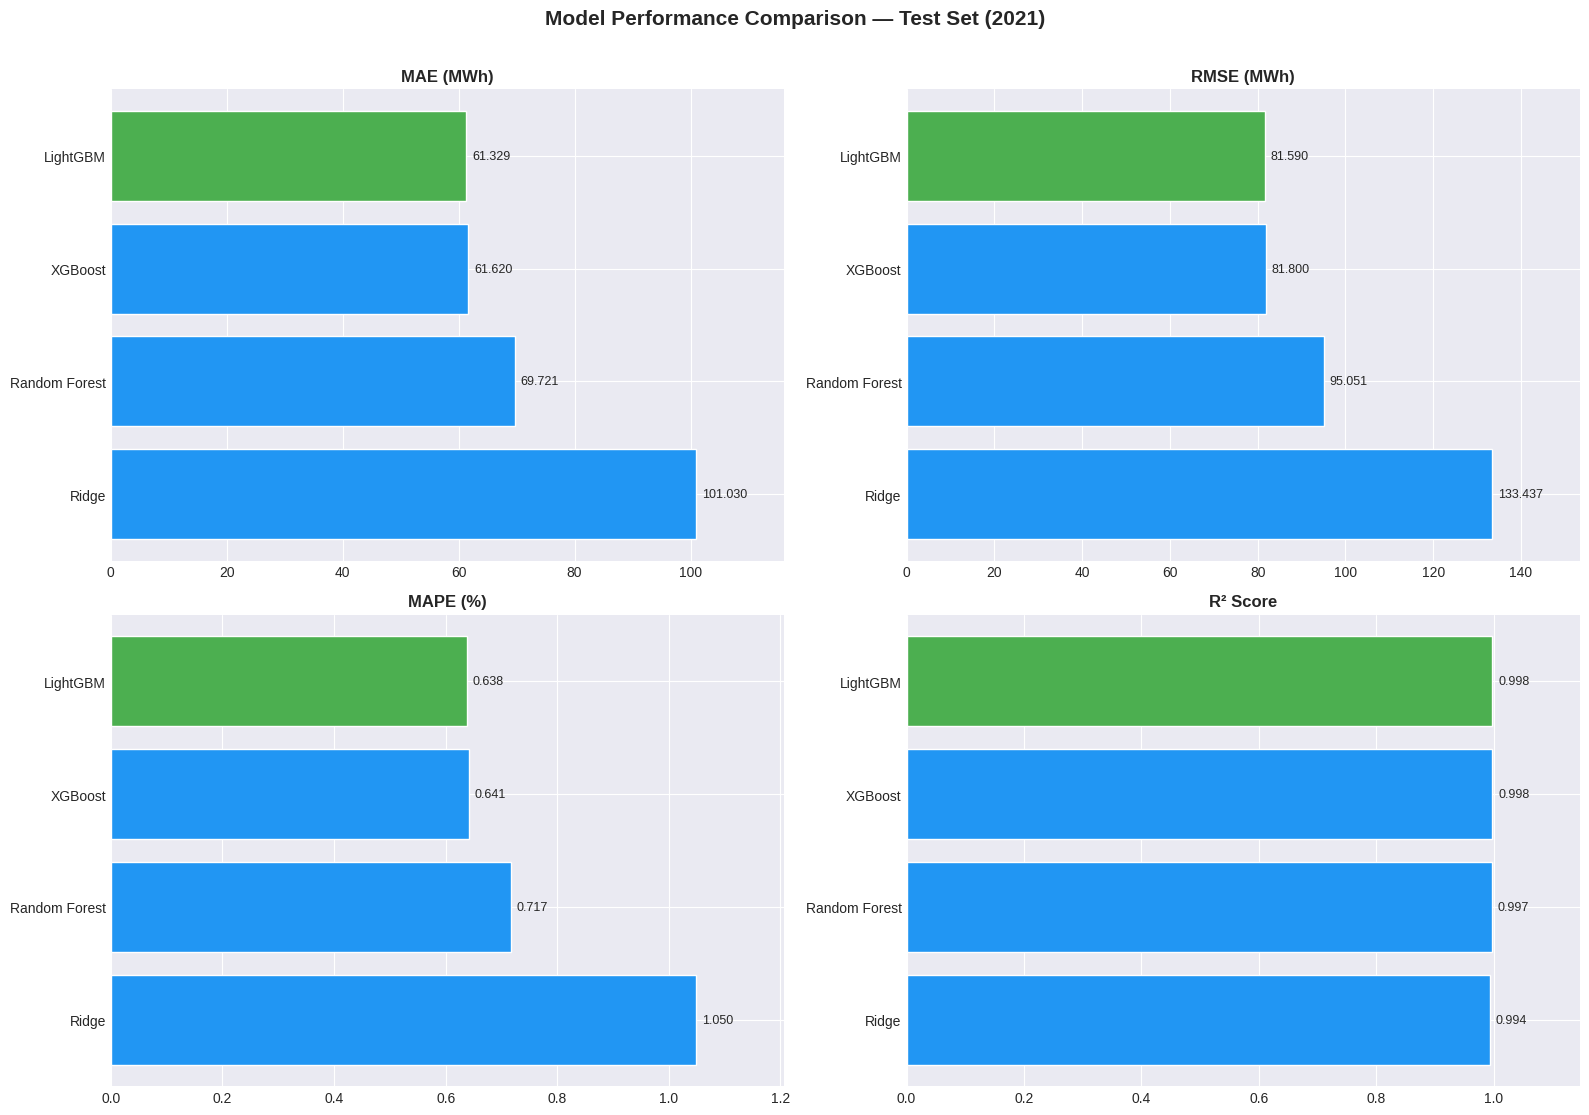


📊 Model Comparison Table:
                 MAE   RMSE  MAPE   R2
model                                 
Ridge         101.03 133.44  1.05 0.99
Random Forest  69.72  95.05  0.72 1.00
XGBoost        61.62  81.80  0.64 1.00
LightGBM       61.33  81.59  0.64 1.00

🏆 Best R²: LightGBM
🏆 Best MAPE: LightGBM


In [20]:
# ─── Model Comparison Visualization ─────────────────────────────────────────
df_results = pd.DataFrame(test_results)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Model Performance Comparison — Test Set (2021)',
             fontsize=15, fontweight='bold', y=1.01)

metrics_plot = ['MAE', 'RMSE', 'MAPE', 'R2']
titles_plot  = ['MAE (MWh)', 'RMSE (MWh)', 'MAPE (%)', 'R² Score']
best_fn      = [min, min, min, max]  # Lower is better for MAE/RMSE/MAPE, higher for R2

for ax, metric, title, best in zip(axes.flatten(), metrics_plot, titles_plot, best_fn):
    vals  = df_results[metric].values
    names = df_results['model'].values
    best_val = best(vals)
    colors_bar = [PALETTE[2] if v == best_val else PALETTE[0] for v in vals]
    bars = ax.barh(names, vals, color=colors_bar, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.01 * max(vals), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, max(vals) * 1.15)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Model Comparison Table:")
print(df_results.set_index('model').to_string())
print(f"\n🏆 Best R²: {df_results.loc[df_results['R2'].idxmax(), 'model']}")
print(f"🏆 Best MAPE: {df_results.loc[df_results['MAPE'].idxmin(), 'model']}")

🏆 Best model selected for visualization: LightGBM


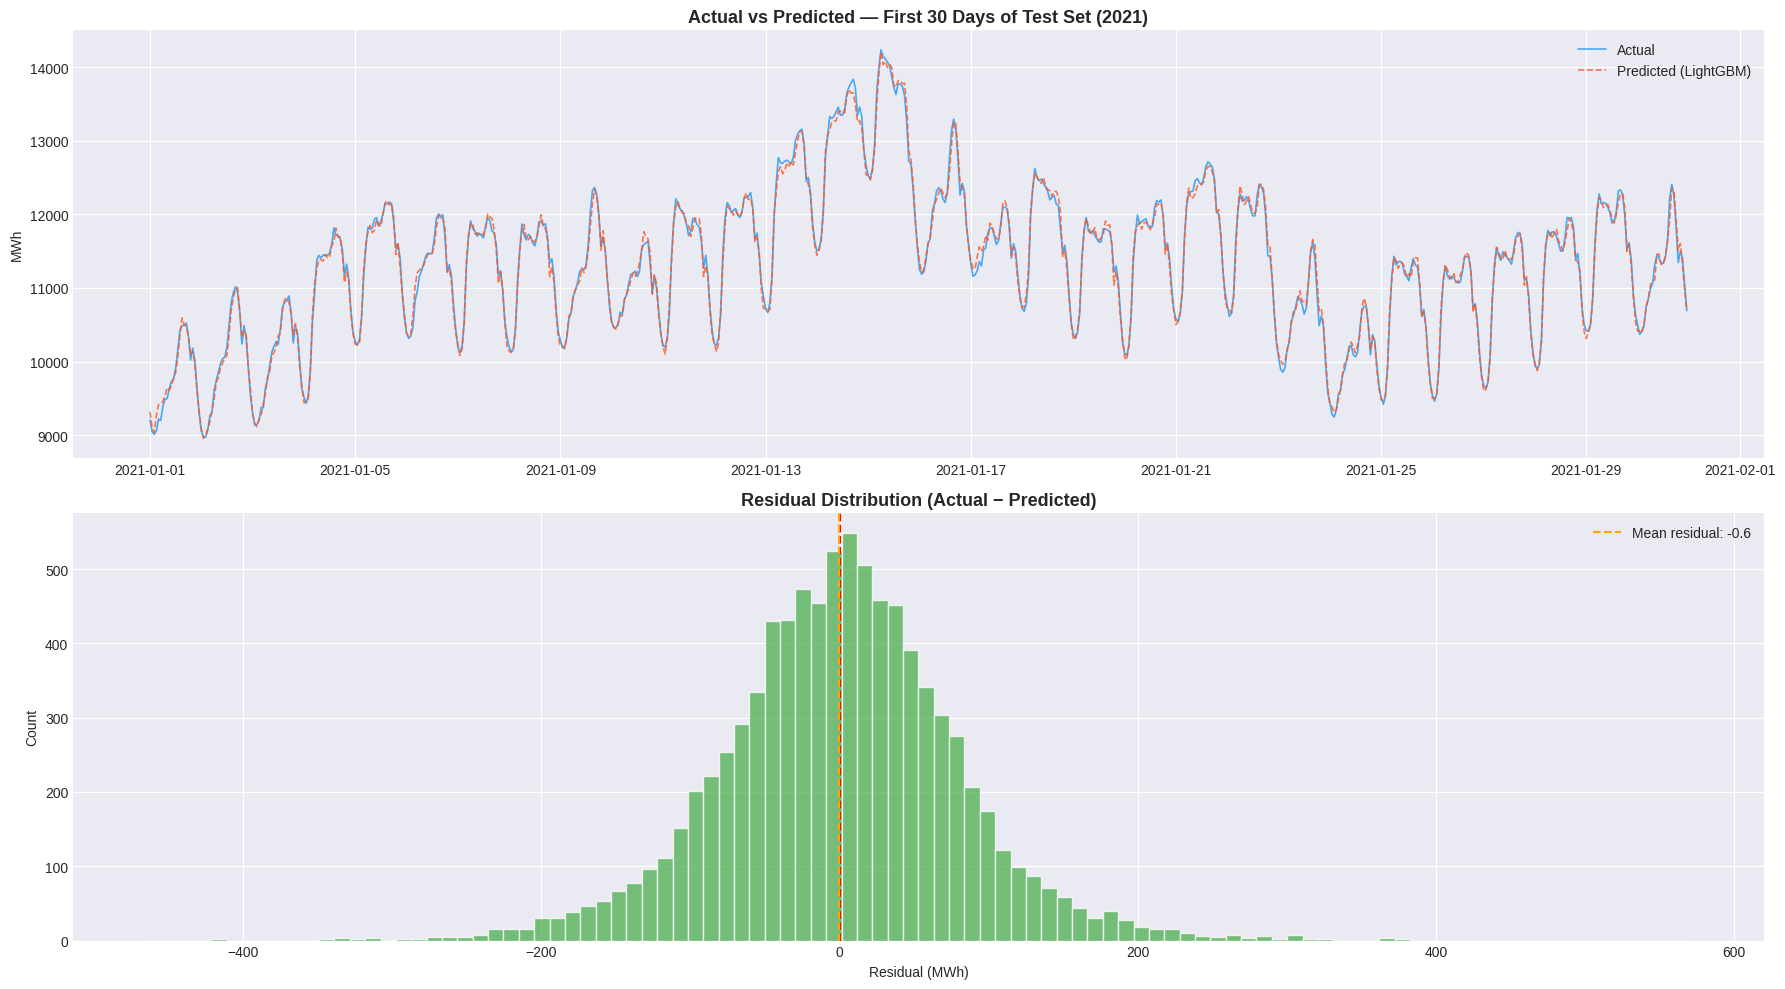

In [21]:
# ─── Actual vs Predicted Plot (Best Model) ───────────────────────────────────
# Identify best model by R²
best_model_name = df_results.loc[df_results['R2'].idxmax(), 'model']
print(f"🏆 Best model selected for visualization: {best_model_name}")

model_map = {
    'Ridge':          (ridge,     X_test_sc),
    'Random Forest':  (rf,        X_test),
    'XGBoost':        (xgb_model, X_test),
    'LightGBM':       (lgb_model, X_test),
}

best_model, best_X = model_map[best_model_name]
if best_model_name == 'LightGBM':
    y_pred_best = best_model.predict(best_X, num_iteration=best_model.best_iteration)
else:
    y_pred_best = best_model.predict(best_X)

test_dates = df_feat.loc[mask_test, 'start_time'].values

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Time-series comparison (first 30 days)
n_show = 30 * 24
axes[0].plot(test_dates[:n_show], y_test.values[:n_show],
             label='Actual', linewidth=1.2, color=PALETTE[0], alpha=0.8)
axes[0].plot(test_dates[:n_show], y_pred_best[:n_show],
             label=f'Predicted ({best_model_name})',
             linewidth=1.2, color=PALETTE[1], alpha=0.8, linestyle='--')
axes[0].set_title(f'Actual vs Predicted — First 30 Days of Test Set (2021)',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('MWh')
axes[0].legend(loc='upper right')

# Residuals distribution
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=100, color=PALETTE[2], alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean residual: {residuals.mean():.1f}')
axes[1].set_title('Residual Distribution (Actual − Predicted)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual (MWh)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

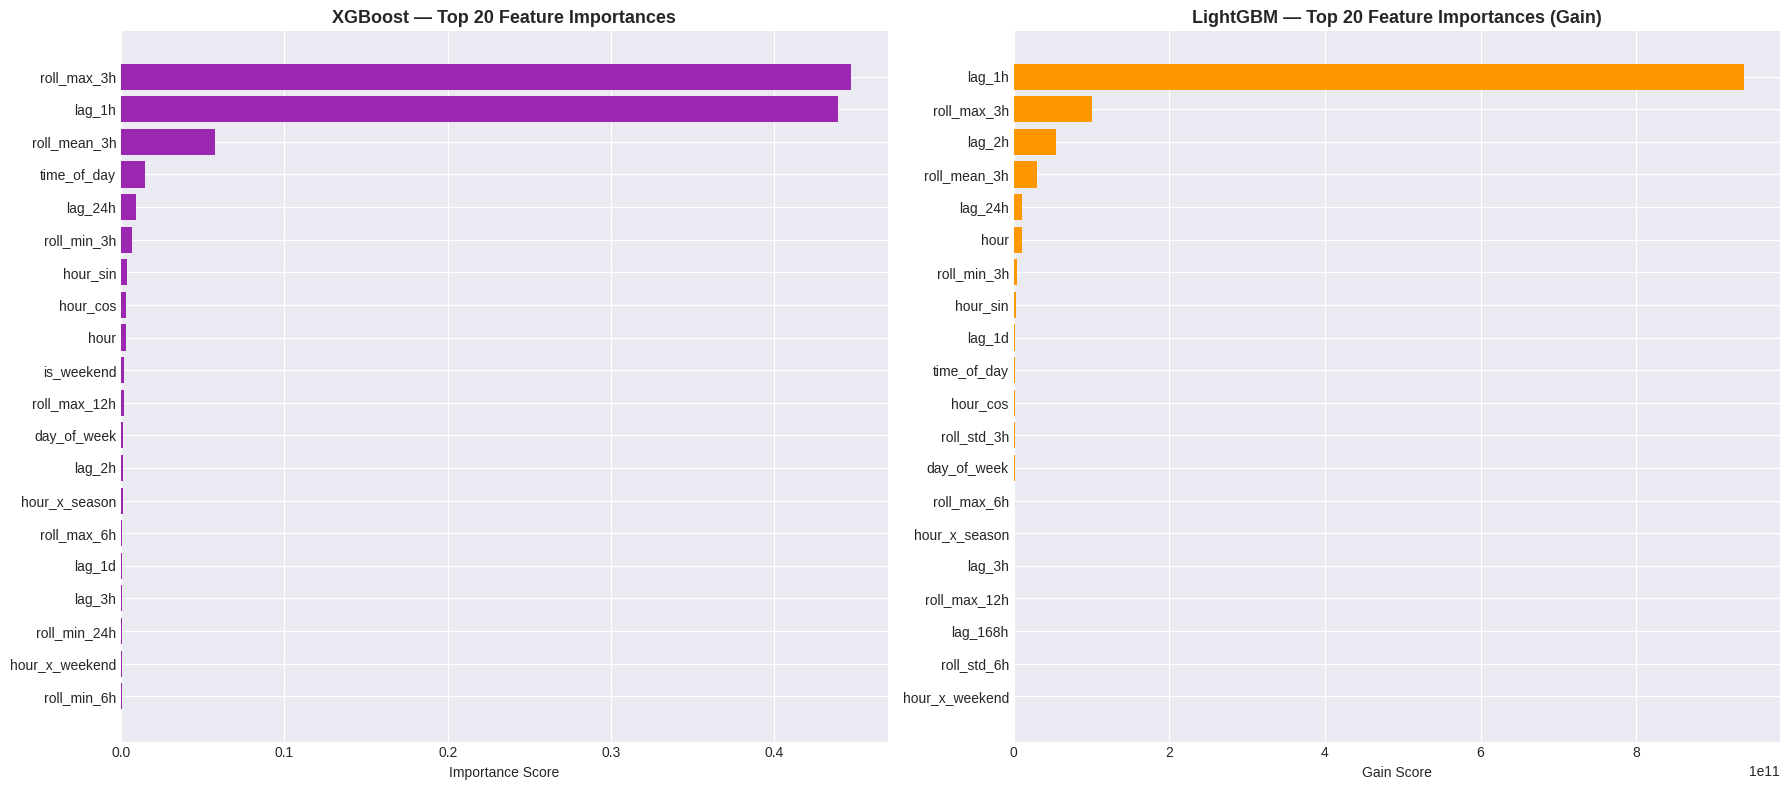

✅ Saved: feature_importance.png


In [22]:
# ─── Feature Importance (XGBoost & LightGBM) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost feature importance
xgb_imp = pd.Series(
    xgb_model.feature_importances_, index=FEATURES
).nlargest(20)
axes[0].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color=PALETTE[3])
axes[0].set_title('XGBoost — Top 20 Feature Importances', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# LightGBM feature importance
lgb_imp = pd.Series(
    lgb_model.feature_importance(importance_type='gain'),
    index=lgb_model.feature_name()
).nlargest(20)
axes[1].barh(lgb_imp.index[::-1], lgb_imp.values[::-1], color=PALETTE[4])
axes[1].set_title('LightGBM — Top 20 Feature Importances (Gain)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gain Score')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance.png")

## 🔮 9. Future Energy Forecasting

### How the Prediction Works

```
INPUT: Start Date + End Date
         │
         ▼
Generate future hourly timestamps
         │
         ▼
Build features: calendric + cyclical + Fourier
         │
         ▼
Rolling lag features: seeded from last N hours of actual data
         │
         ▼
Best ML Model predicts → MWh per hour
         │
         ▼
Plot future forecast chart + total consumption summary
```

> ⚠️ **Note on future lags**: Since lag features depend on future predictions themselves, we use an iterative (recursive) forecasting approach — each hour's prediction becomes the lag input for the next hour.

In [23]:
# ─── Forecasting Engine ──────────────────────────────────────────────────────

def build_single_row_features(timestamp: pd.Timestamp,
                               lag_buffer: dict,
                               t_idx: int) -> dict:
    """
    Build features for a single future timestamp.
    
    Parameters
    ----------
    timestamp   : The future timestamp to build features for.
    lag_buffer  : dict mapping lag size (hours) → list of past values.
    t_idx       : Integer index from the dataset start (for Fourier terms).
    
    Returns
    -------
    dict of feature_name → value
    """
    row = {}
    ts = timestamp
    h, dow, doy = ts.hour, ts.dayofweek, ts.dayofyear
    month, year  = ts.month, ts.year

    # Calendric
    row['hour']           = h
    row['day_of_week']    = dow
    row['day_of_month']   = ts.day
    row['day_of_year']    = doy
    row['week_of_year']   = ts.isocalendar()[1]
    row['month']          = month
    row['quarter']        = ts.quarter
    row['year']           = year
    row['is_weekend']     = int(dow >= 5)
    row['is_month_start'] = int(ts.is_month_start)
    row['is_month_end']   = int(ts.is_month_end)
    season_map = {12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3}
    row['season']        = season_map[month]
    row['time_of_day']   = 0 if h<6 else (1 if h<12 else (2 if h<18 else 3))

    # Cyclical
    row['hour_sin']   = np.sin(2 * np.pi * h      / 24)
    row['hour_cos']   = np.cos(2 * np.pi * h      / 24)
    row['dow_sin']    = np.sin(2 * np.pi * dow    / 7)
    row['dow_cos']    = np.cos(2 * np.pi * dow    / 7)
    row['month_sin']  = np.sin(2 * np.pi * month  / 12)
    row['month_cos']  = np.cos(2 * np.pi * month  / 12)
    row['doy_sin']    = np.sin(2 * np.pi * doy    / 365.25)
    row['doy_cos']    = np.cos(2 * np.pi * doy    / 365.25)

    # Lag features from buffer
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        buf = lag_buffer.get(lag, [])
        row[f'lag_{lag}h'] = buf[-1] if len(buf) >= lag else np.nan
    # Aliases used in feature list
    row['lag_1w'] = lag_buffer.get(168, [np.nan])[-1]
    row['lag_1d'] = lag_buffer.get(24,  [np.nan])[-1]

    # Rolling statistics from buffer (use last 'w' values)
    windows = {'3h':3, '6h':6, '12h':12, '24h':24, '48h':48, '1w':168}
    for name, w in windows.items():
        buf = lag_buffer.get(w, [])
        window_data = np.array(buf[-w:]) if len(buf) > 0 else np.array([np.nan])
        row[f'roll_mean_{name}'] = np.nanmean(window_data)
        row[f'roll_std_{name}']  = np.nanstd(window_data)
        row[f'roll_min_{name}']  = np.nanmin(window_data)
        row[f'roll_max_{name}']  = np.nanmax(window_data)

    # Expanding mean (approx from buffer)
    all_buf = lag_buffer.get(168, [])
    row['expand_mean'] = np.nanmean(all_buf) if all_buf else np.nan

    # Fourier harmonics
    for k in [1, 2, 3]:
        row[f'fourier_daily_sin_{k}'] = np.sin(2 * np.pi * k * t_idx / 24)
        row[f'fourier_daily_cos_{k}'] = np.cos(2 * np.pi * k * t_idx / 24)
    for k in [1, 2]:
        row[f'fourier_weekly_sin_{k}'] = np.sin(2 * np.pi * k * t_idx / 168)
        row[f'fourier_weekly_cos_{k}'] = np.cos(2 * np.pi * k * t_idx / 168)

    # Interaction features
    row['hour_x_weekend'] = h * row['is_weekend']
    row['hour_x_season']  = h * row['season']
    row['min_year'] = df_feat['year'].min()
    row['month_x_year']   = month * (year - df_feat['year'].min())

    return row


def forecast_future(start_date: str,
                    end_date:   str,
                    model_name: str = 'LightGBM',
                    freq: str = 'h') -> pd.DataFrame:
    """
    Iterative future energy consumption forecast.

    Parameters
    ----------
    start_date : e.g. '2022-01-01'
    end_date   : e.g. '2022-03-31'
    model_name : 'Ridge' | 'Random Forest' | 'XGBoost' | 'LightGBM'
    freq       : 'h' (hourly)

    Returns
    -------
    DataFrame with ['timestamp', 'predicted_mwh']
    """
    print(f"\n🔮 Forecasting: {start_date} → {end_date} using {model_name}")

    # Build future timestamps
    future_timestamps = pd.date_range(start=start_date, end=end_date, freq=freq)
    print(f"   Total hours to forecast: {len(future_timestamps):,}")

    # Seed lag buffer with the LAST 168 hours of actual data
    seed_data = df_raw.sort_values('start_time').tail(200)['consumption_mwh'].values
    rolling_history = list(seed_data[-168:])  # keep last 168h max

    # t_idx starts from end of training data
    t_idx_start = len(df_feat)

    # Lag buffer: key = max_lag, value = deque of past values
    from collections import deque
    max_lag = 168
    buffer = deque(rolling_history, maxlen=max_lag)

    # Build per-lag views
    def get_lag_buffer(buf, lags=[1,2,3,6,12,24,48,168]):
        result = {}
        buf_list = list(buf)
        for lag in lags:
            result[lag] = buf_list  # full history, indexing done in build_single_row
        return result

    predictions = []

    # Load model
    model_dispatch = {
        'Ridge':         ridge,
        'Random Forest': rf,
        'XGBoost':       xgb_model,
        'LightGBM':      lgb_model,
    }
    mdl = model_dispatch[model_name]

    for i, ts in enumerate(future_timestamps):
        lag_buf = get_lag_buffer(buffer)
        row = build_single_row_features(ts, lag_buf, t_idx_start + i)

        # Build row in correct feature order
        X_row = pd.DataFrame([row])[FEATURES]
        X_row = X_row.fillna(method='ffill').fillna(0)

        if model_name == 'Ridge':
            X_row_sc = scaler.transform(X_row)
            pred = float(mdl.predict(X_row_sc)[0])
        elif model_name == 'LightGBM':
            pred = float(mdl.predict(X_row, num_iteration=mdl.best_iteration)[0])
        else:
            pred = float(mdl.predict(X_row)[0])

        pred = max(pred, 0)  # Clip negatives
        predictions.append({'timestamp': ts, 'predicted_mwh': pred})
        buffer.append(pred)

        if (i + 1) % 500 == 0:
            print(f"   [{i+1:>5}/{len(future_timestamps)}] {ts}  →  {pred:.1f} MWh")

    df_pred = pd.DataFrame(predictions)
    print(f"\n✅ Forecast complete! {len(df_pred):,} hourly predictions generated.")
    return df_pred


print("✅ Forecasting engine ready!")

✅ Forecasting engine ready!


## 📅 10. Run Your Custom Forecast

### ✏️ Enter your desired forecast window below:

In [31]:
# ════════════════════════════════════════════════════════════════
#   ✏️  CONFIGURE YOUR FORECAST HERE
# ════════════════════════════════════════════════════════════════

FORECAST_START = '2018-01-01'   # ← Change this (YYYY-MM-DD)
FORECAST_END   = '2019-03-31'   # ← Change this (YYYY-MM-DD)

# Best model: 'LightGBM' | 'XGBoost' | 'Random Forest' | 'Ridge'
FORECAST_MODEL = 'LightGBM'

# ════════════════════════════════════════════════════════════════

# Run forecast
df_forecast = forecast_future(
    start_date=FORECAST_START,
    end_date=FORECAST_END,
    model_name=FORECAST_MODEL
)

# ─── Summary Statistics ───────────────────────────────────────────────────────
total_energy    = df_forecast['predicted_mwh'].sum()
avg_hourly      = df_forecast['predicted_mwh'].mean()
peak_hour       = df_forecast.loc[df_forecast['predicted_mwh'].idxmax()]
trough_hour     = df_forecast.loc[df_forecast['predicted_mwh'].idxmin()]
n_days          = (pd.to_datetime(FORECAST_END) - pd.to_datetime(FORECAST_START)).days + 1

print("\n" + "=" * 60)
print("       📊  FORECAST SUMMARY REPORT")
print("=" * 60)
print(f"  Period               : {FORECAST_START} → {FORECAST_END}")
print(f"  Duration             : {n_days} days ({len(df_forecast):,} hours)")
print(f"  Model Used           : {FORECAST_MODEL}")
print("-" * 60)
print(f"  ⚡ TOTAL ENERGY       : {total_energy:>15,.1f} MWh")
print(f"  ⚡ TOTAL ENERGY       : {total_energy/1e6:>15.4f} TWh")
print(f"  📈 Average per Hour  : {avg_hourly:>15,.1f} MWh")
print(f"  📈 Average per Day   : {total_energy/n_days:>15,.1f} MWh")
print(f"  🔺 Peak Consumption  : {peak_hour['predicted_mwh']:>15,.1f} MWh")
print(f"     Peak Timestamp    : {peak_hour['timestamp']}")
print(f"  🔻 Min Consumption   : {trough_hour['predicted_mwh']:>15,.1f} MWh")
print(f"     Min Timestamp     : {trough_hour['timestamp']}")
print("=" * 60)


🔮 Forecasting: 2018-01-01 → 2019-03-31 using LightGBM
   Total hours to forecast: 10,897
   [  500/10897] 2018-01-21 19:00:00  →  9405.3 MWh
   [ 1000/10897] 2018-02-11 15:00:00  →  9507.2 MWh
   [ 1500/10897] 2018-03-04 11:00:00  →  8948.1 MWh
   [ 2000/10897] 2018-03-25 07:00:00  →  9400.3 MWh
   [ 2500/10897] 2018-04-15 03:00:00  →  9169.8 MWh
   [ 3000/10897] 2018-05-05 23:00:00  →  8593.4 MWh
   [ 3500/10897] 2018-05-26 19:00:00  →  9349.5 MWh
   [ 4000/10897] 2018-06-16 15:00:00  →  9660.1 MWh
   [ 4500/10897] 2018-07-07 11:00:00  →  9374.3 MWh
   [ 5000/10897] 2018-07-28 07:00:00  →  9798.9 MWh
   [ 5500/10897] 2018-08-18 03:00:00  →  9299.8 MWh
   [ 6000/10897] 2018-09-07 23:00:00  →  8689.4 MWh
   [ 6500/10897] 2018-09-28 19:00:00  →  9679.1 MWh
   [ 7000/10897] 2018-10-19 15:00:00  →  10265.7 MWh
   [ 7500/10897] 2018-11-09 11:00:00  →  10106.5 MWh
   [ 8000/10897] 2018-11-30 07:00:00  →  10188.3 MWh
   [ 8500/10897] 2018-12-21 03:00:00  →  9811.8 MWh
   [ 9000/10897] 2019-0

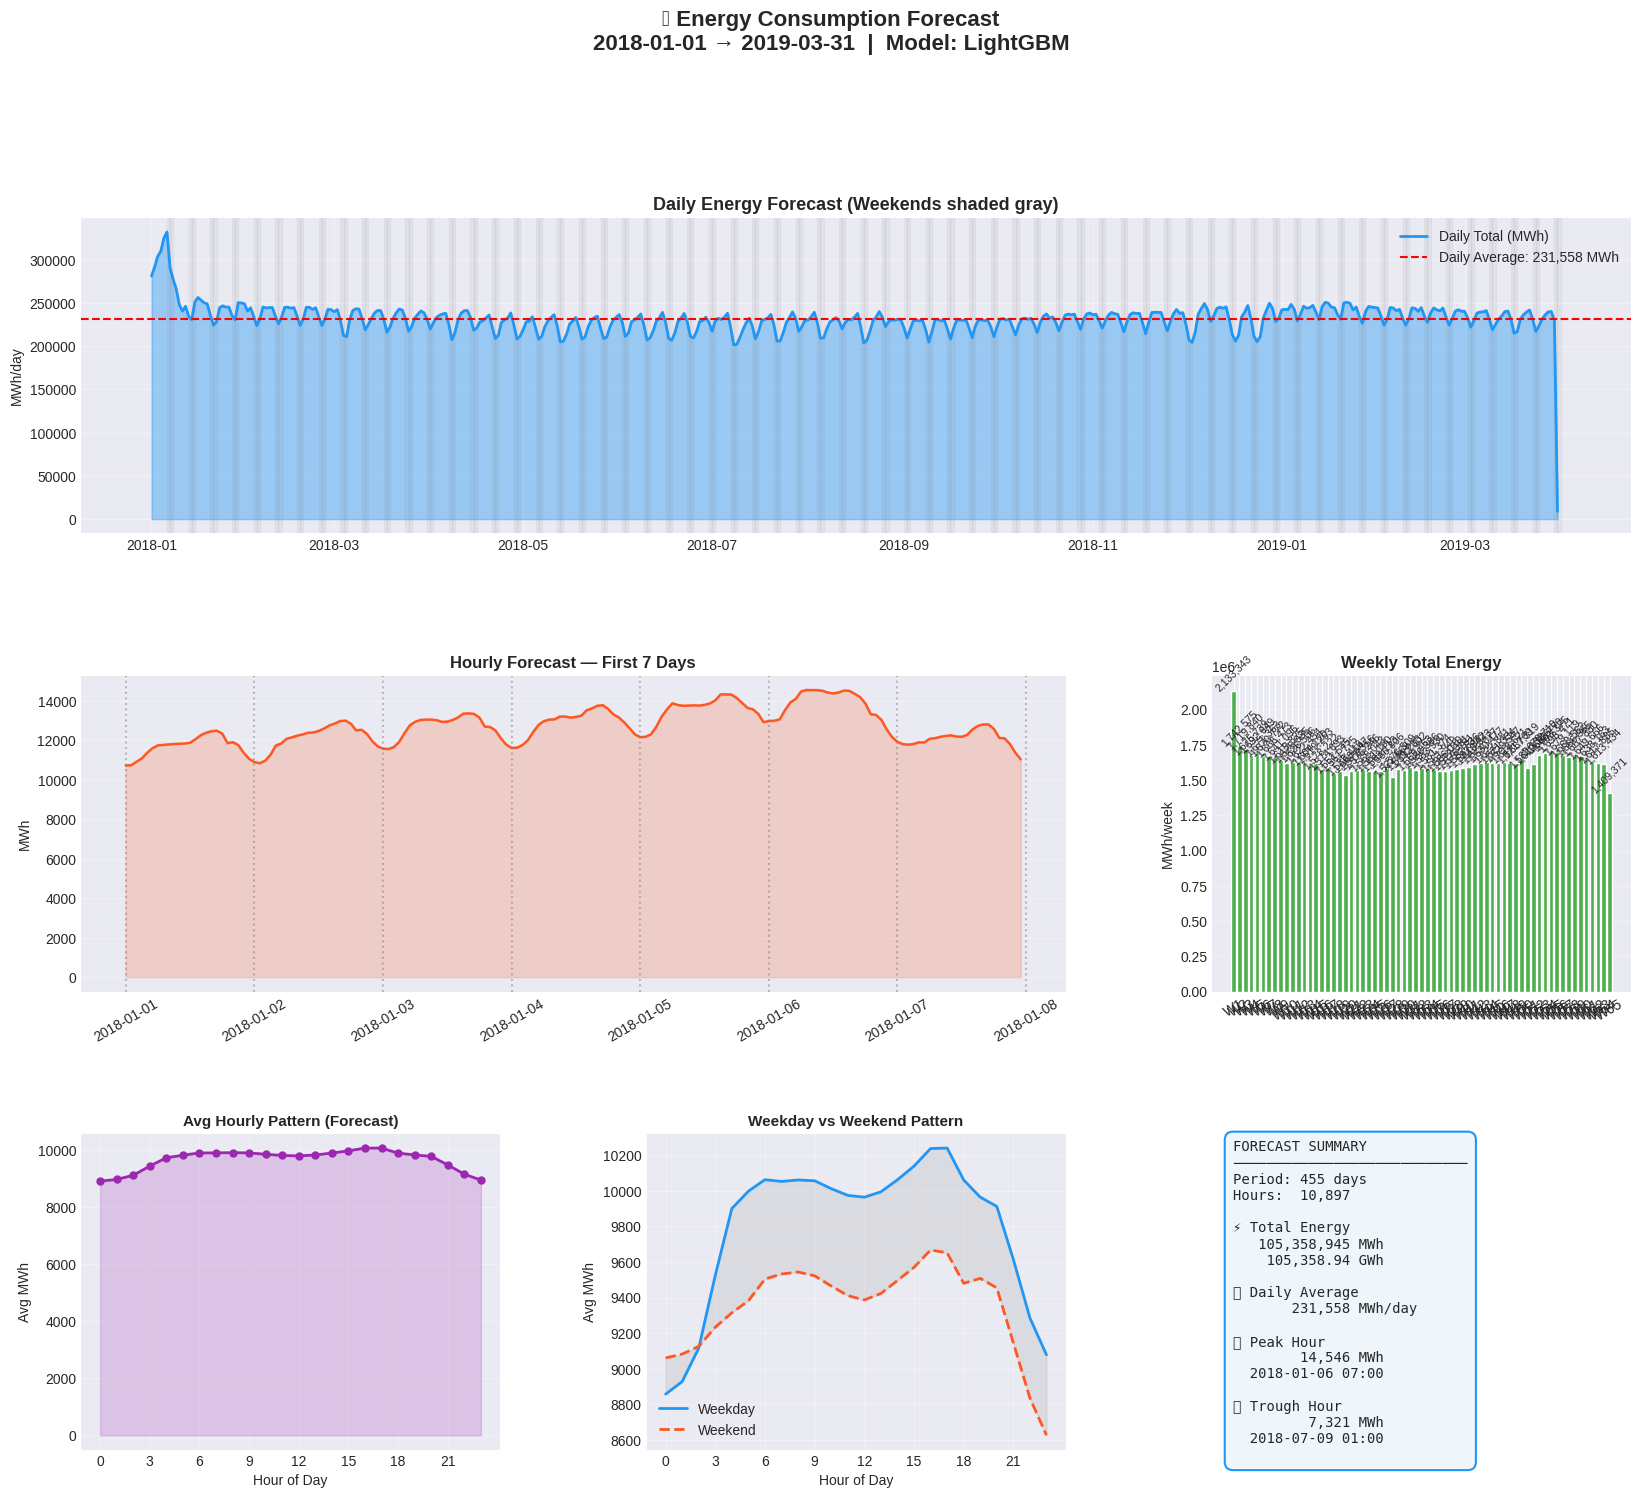


✅ Forecast chart saved!


In [32]:
# ─── Forecast Visualization Dashboard ───────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle(f'⚡ Energy Consumption Forecast\n{FORECAST_START} → {FORECAST_END}  |  Model: {FORECAST_MODEL}',
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Full Forecast Time Series ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
daily_forecast = df_forecast.set_index('timestamp')['predicted_mwh'].resample('D').sum()
ax1.fill_between(daily_forecast.index, daily_forecast.values,
                 alpha=0.4, color=PALETTE[0])
ax1.plot(daily_forecast.index, daily_forecast.values,
         color=PALETTE[0], linewidth=2, label='Daily Total (MWh)')
ax1.axhline(daily_forecast.mean(), color='red', linestyle='--', linewidth=1.5,
             label=f'Daily Average: {daily_forecast.mean():,.0f} MWh')
# Highlight weekends
for date in daily_forecast.index:
    if date.dayofweek >= 5:
        ax1.axvspan(date, date + pd.Timedelta(days=1), alpha=0.08, color='gray')
ax1.set_title('Daily Energy Forecast (Weekends shaded gray)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MWh/day')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# ── Panel 2: Hourly Detail (First 7 Days) ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
first_week = df_forecast.head(7 * 24)
ax2.plot(first_week['timestamp'], first_week['predicted_mwh'],
         color=PALETTE[1], linewidth=1.8)
ax2.fill_between(first_week['timestamp'], first_week['predicted_mwh'],
                 alpha=0.2, color=PALETTE[1])
for d in pd.date_range(FORECAST_START, periods=8, freq='D'):
    ax2.axvline(d, color='gray', linestyle=':', alpha=0.5)
ax2.set_title('Hourly Forecast — First 7 Days', fontsize=12, fontweight='bold')
ax2.set_ylabel('MWh')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, alpha=0.3)

# ── Panel 3: Weekly Summary Bar ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
weekly = df_forecast.set_index('timestamp')['predicted_mwh'].resample('W').sum()
bars = ax3.bar(range(len(weekly)), weekly.values, color=PALETTE[2], edgecolor='white')
ax3.set_xticks(range(len(weekly)))
ax3.set_xticklabels([f'W{i+1}' for i in range(len(weekly))], rotation=30)
ax3.set_title('Weekly Total Energy', fontsize=12, fontweight='bold')
ax3.set_ylabel('MWh/week')
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{bar.get_height():,.0f}', ha='center', fontsize=7.5, rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# ── Panel 4: Average Hourly Pattern ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
df_forecast['hour'] = df_forecast['timestamp'].dt.hour
hourly_pattern = df_forecast.groupby('hour')['predicted_mwh'].mean()
ax4.plot(hourly_pattern.index, hourly_pattern.values,
         marker='o', markersize=5, linewidth=2, color=PALETTE[3])
ax4.fill_between(hourly_pattern.index, hourly_pattern.values, alpha=0.2, color=PALETTE[3])
ax4.set_title('Avg Hourly Pattern (Forecast)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('Avg MWh')
ax4.set_xticks(range(0, 24, 3))
ax4.grid(True, alpha=0.3)

# ── Panel 5: Weekday vs Weekend ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
df_forecast['is_weekend'] = df_forecast['timestamp'].dt.dayofweek >= 5
wkd = df_forecast[~df_forecast['is_weekend']].groupby('hour')['predicted_mwh'].mean()
wke = df_forecast[ df_forecast['is_weekend']].groupby('hour')['predicted_mwh'].mean()
ax5.plot(wkd.index, wkd.values, label='Weekday', color=PALETTE[0], linewidth=2)
ax5.plot(wke.index, wke.values, label='Weekend', color=PALETTE[1], linewidth=2, linestyle='--')
ax5.fill_between(wkd.index, wkd.values, wke.values, alpha=0.15, color='gray')
ax5.set_title('Weekday vs Weekend Pattern', fontsize=11, fontweight='bold')
ax5.set_xlabel('Hour of Day')
ax5.set_ylabel('Avg MWh')
ax5.set_xticks(range(0, 24, 3))
ax5.legend()
ax5.grid(True, alpha=0.3)

# ── Panel 6: Summary Text Box ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
summary_text = (
    f"FORECAST SUMMARY\n"
    f"{'─'*28}\n"
    f"Period: {n_days} days\n"
    f"Hours:  {len(df_forecast):,}\n\n"
    f"⚡ Total Energy\n"
    f"  {total_energy:>12,.0f} MWh\n"
    f"  {total_energy/1000:>12,.2f} GWh\n\n"
    f"📈 Daily Average\n"
    f"  {total_energy/n_days:>12,.0f} MWh/day\n\n"
    f"🔺 Peak Hour\n"
    f"  {peak_hour['predicted_mwh']:>12,.0f} MWh\n"
    f"  {str(peak_hour['timestamp'])[:16]}\n\n"
    f"🔻 Trough Hour\n"
    f"  {trough_hour['predicted_mwh']:>12,.0f} MWh\n"
    f"  {str(trough_hour['timestamp'])[:16]}\n"
)
ax6.text(0.05, 0.98, summary_text, transform=ax6.transAxes,
          va='top', ha='left', fontsize=10,
          fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#EFF6FB',
                    edgecolor=PALETTE[0], linewidth=1.5))

plt.savefig(PLOT_DIR / f'forecast_{FORECAST_START}_to_{FORECAST_END}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Forecast chart saved!")

In [30]:
# ─── Export Forecast to CSV ───────────────────────────────────────────────────
df_forecast_export = df_forecast[['timestamp', 'predicted_mwh']].copy()
df_forecast_export['date']     = df_forecast_export['timestamp'].dt.date
df_forecast_export['hour']     = df_forecast_export['timestamp'].dt.hour
df_forecast_export['day_name'] = df_forecast_export['timestamp'].dt.day_name()

csv_path = OUTPUT_DIR / f'forecast_{FORECAST_START}_to_{FORECAST_END}.csv'
df_forecast_export.to_csv(csv_path, index=False)
print(f"💾 Forecast CSV saved → {csv_path}")
print()
print("📋 Sample forecast output:")
df_forecast_export.head(24)

💾 Forecast CSV saved → /kaggle/working/models/forecast_2025-01-01_to_2025-03-31.csv

📋 Sample forecast output:


,timestamp,predicted_mwh,date,hour,day_name
0,2025-01-01 00:00:00,10691.98,2025-01-01,0,Wednesday
1,2025-01-01 01:00:00,10660.91,2025-01-01,1,Wednesday
2,2025-01-01 02:00:00,10696.66,2025-01-01,2,Wednesday
3,2025-01-01 03:00:00,10820.26,2025-01-01,3,Wednesday
4,2025-01-01 04:00:00,10965.45,2025-01-01,4,Wednesday
5,2025-01-01 05:00:00,11101.80,2025-01-01,5,Wednesday
6,2025-01-01 06:00:00,11281.69,2025-01-01,6,Wednesday
7,2025-01-01 07:00:00,11392.57,2025-01-01,7,Wednesday
8,2025-01-01 08:00:00,11439.36,2025-01-01,8,Wednesday
9,2025-01-01 09:00:00,11457.33,2025-01-01,9,Wednesday


## 💾 11. Saved Files Summary

In [27]:
# ─── List all saved artifacts ────────────────────────────────────────────────
print("=" * 55)
print("  ALL SAVED MODELS & ARTIFACTS")
print("=" * 55)

all_files = sorted(Path(OUTPUT_DIR).rglob('*'))
for f in all_files:
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  ✅  {f.name:<40}  {size_kb:>9.1f} KB")

print()
print("=" * 55)
print("  PLOTS SAVED")
print("=" * 55)
for f in sorted(Path(PLOT_DIR).rglob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f"  🖼️   {f.name:<45}  {size_kb:>7.1f} KB")

print("\n🎉 All done!")

  ALL SAVED MODELS & ARTIFACTS
  ✅  feature_scaler.pkl                              3.4 KB
  ✅  forecast_2022-01-01_to_2022-03-31.csv         125.1 KB
  ✅  lightgbm_model.txt                           5388.7 KB
  ✅  lstm_best.keras                              3846.2 KB
  ✅  lstm_final.keras                             3846.2 KB
  ✅  lstm_scaler.pkl                                 0.7 KB
  ✅  prophet_model.pkl                             135.0 KB
  ✅  random_forest.pkl                          189206.8 KB
  ✅  ridge_regression.pkl                            1.1 KB
  ✅  test_results.json                               0.6 KB
  ✅  xgboost_model.json                          15107.5 KB

  PLOTS SAVED
  🖼️   actual_vs_predicted.png                          293.0 KB
  🖼️   eda_distribution.png                             126.7 KB
  🖼️   eda_seasonal_patterns.png                        315.3 KB
  🖼️   eda_time_series_overview.png                     305.1 KB
  🖼️   feature_correlation.png    

---
## 📚 12. How to Load Saved Models (Quick Reference)

```python
import joblib, pickle, xgboost as xgb, lightgbm as lgb
from tensorflow.keras.models import load_model

# Ridge Regression
ridge      = joblib.load('models/ridge_regression.pkl')

# Random Forest
rf         = joblib.load('models/random_forest.pkl')

# XGBoost
xgb_model  = xgb.XGBRegressor()
xgb_model.load_model('models/xgboost_model.json')

# LightGBM
lgb_model  = lgb.Booster(model_file='models/lightgbm_model.txt')

# Prophet
with open('models/prophet_model.pkl', 'rb') as f:
    prophet_model = pickle.load(f)

# LSTM
lstm_model = load_model('models/lstm_final.keras')
lstm_sc    = joblib.load('models/lstm_scaler.pkl')

# Feature Scaler
scaler     = joblib.load('models/feature_scaler.pkl')
```

---
*Notebook built for Kaggle / local. Data: Hourly electricity consumption 2016–2021.*